In [2]:
from db.db_query import get_monthly_total_spending_trend, get_weekly_total_spending_trend, get_monthly_spending_breakdown_by_category, get_overall_category_expense_proportions, get_transaction_frequency_vs_avg_spend_size_by_month
import pandas as pd
import matplotlib.pyplot as plt

Using timezone: EEST


In [3]:
monthly_total_spending_trend = get_monthly_total_spending_trend()
monthly_total_spending_trend_df = pd.DataFrame(monthly_total_spending_trend)

In [4]:
monthly_total_spending_trend_df.columns = ["month", "total_spending"]

In [5]:
monthly_total_spending_trend_df

,month,total_spending
0,2025-01,10898.98
1,2025-02,8568.72
2,2025-03,8012.57
3,2025-04,15774.86
4,2025-05,8260.76
5,2025-06,11797.56
6,2025-07,10403.99
7,2025-08,15965.14
8,2025-09,10083.84
9,2025-10,14244.44


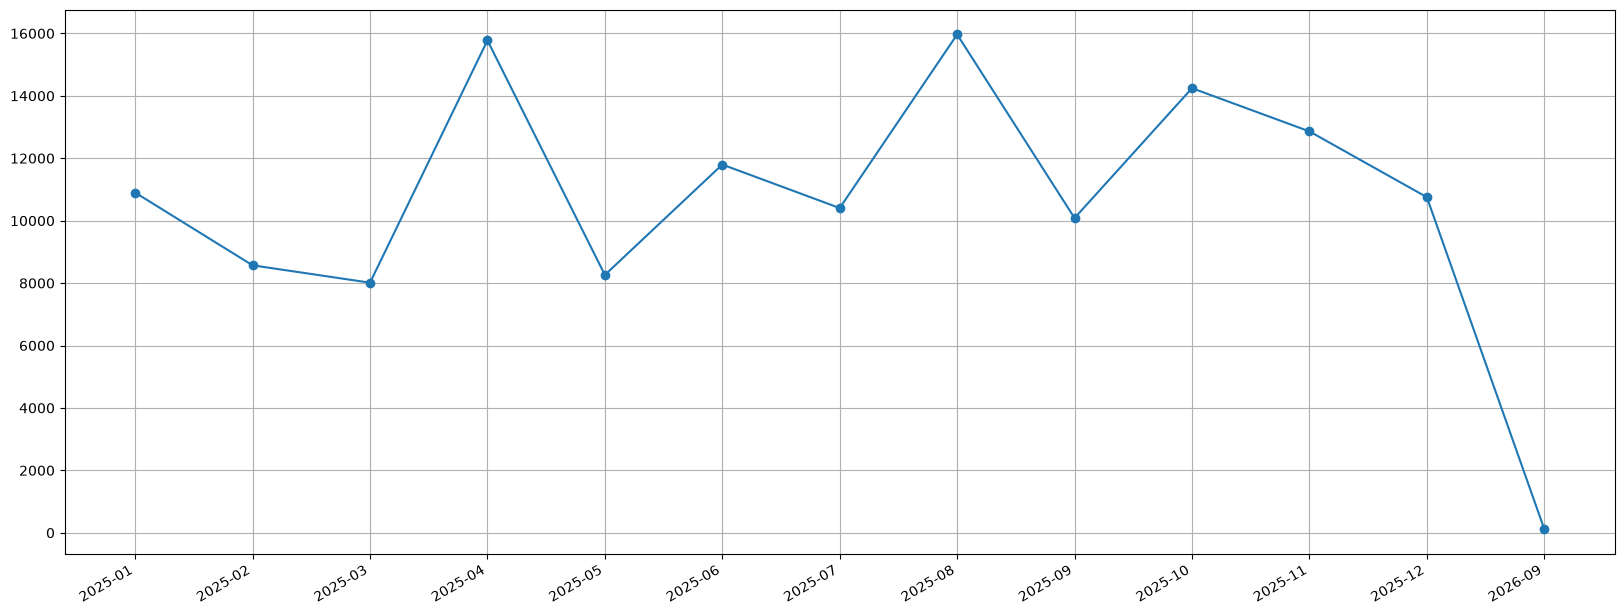

In [6]:
fig, ax = plt.subplots(1, figsize = (20, 8))
ax.grid()
fig.autofmt_xdate()
plt.plot(monthly_total_spending_trend_df['month'], 
         monthly_total_spending_trend_df['total_spending'], 
         marker='o')
plt.show()


In [7]:
weekly_total_spending_trend = get_weekly_total_spending_trend()
weekly_total_spending_trend_df = pd.DataFrame(weekly_total_spending_trend)

In [9]:
weekly_total_spending_trend_df.columns = ["week", "total_spending"]

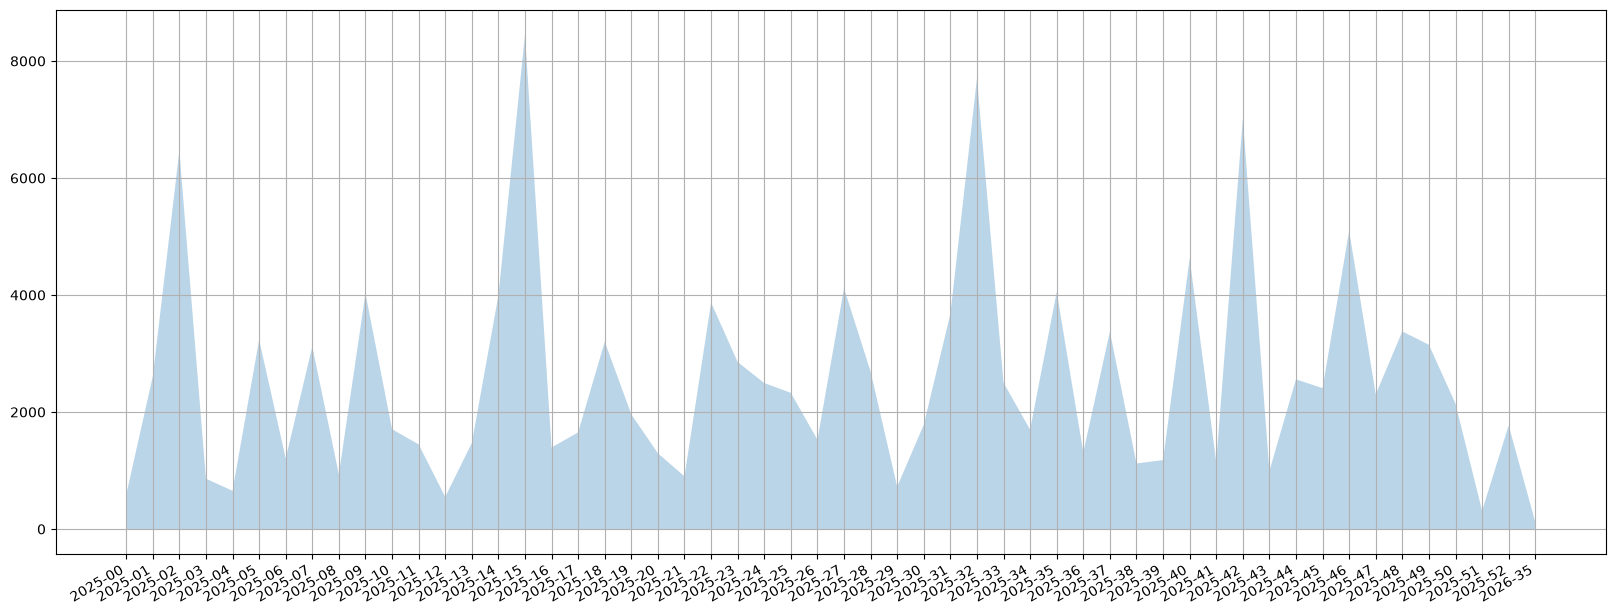

In [15]:
fig, ax = plt.subplots(1, figsize = (20, 8))
ax.grid()
fig.autofmt_xdate()
plt.fill_between(weekly_total_spending_trend_df['week'], 
         weekly_total_spending_trend_df['total_spending'], 
         alpha=0.3)
plt.show()


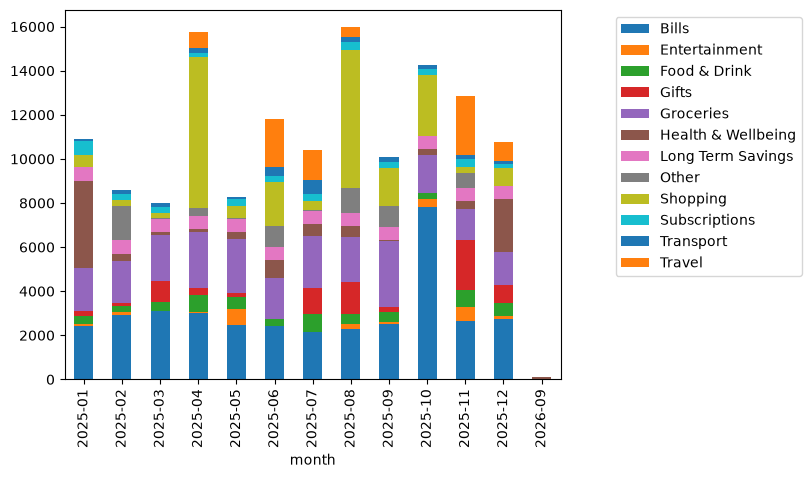

In [18]:
monthly_spending_breakdown_by_category = get_monthly_spending_breakdown_by_category()
monthly_spending_breakdown_by_category_df = pd.DataFrame(monthly_spending_breakdown_by_category)
monthly_spending_breakdown_by_category_df.columns = ["month", "category", "total_spending"]
monthly_spending_breakdown_by_category_df.pivot(index='month', columns='category', values='total_spending').plot(kind='bar', stacked=True).legend(bbox_to_anchor=(1.5, 1))

In [19]:
overall_category_expense_proportions = get_overall_category_expense_proportions()
overall_category_expense_proportions_df = pd.DataFrame(overall_category_expense_proportions)
overall_category_expense_proportions_df.columns = ["category", "total_spending", "percentage"]

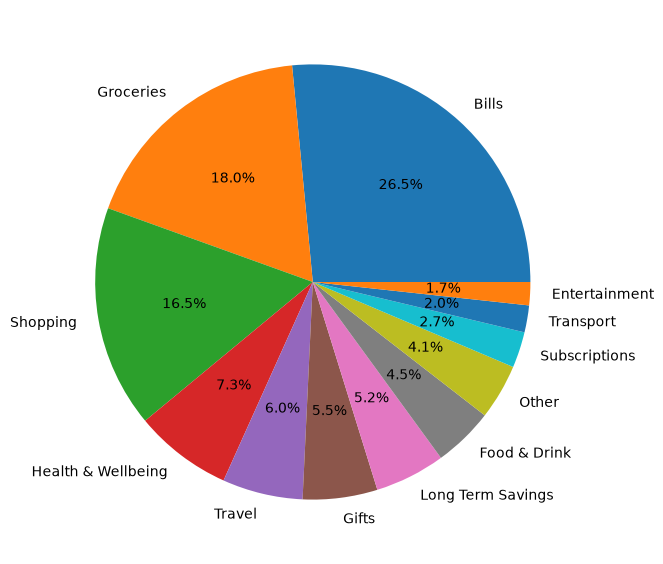

In [20]:
fig, ax = plt.subplots(1, figsize = (20, 8))
ax.grid()
fig.autofmt_xdate()
plt.pie(overall_category_expense_proportions_df['total_spending'], labels=overall_category_expense_proportions_df['category'], autopct='%1.1f%%')
plt.show()

In [22]:
transaction_frequency_vs_avg_spend_size_by_month = get_transaction_frequency_vs_avg_spend_size_by_month()
transaction_frequency_vs_avg_spend_size_by_month_df = pd.DataFrame(transaction_frequency_vs_avg_spend_size_by_month)
transaction_frequency_vs_avg_spend_size_by_month_df.columns = ["month", "transaction_count", "avg_transaction_amount"]

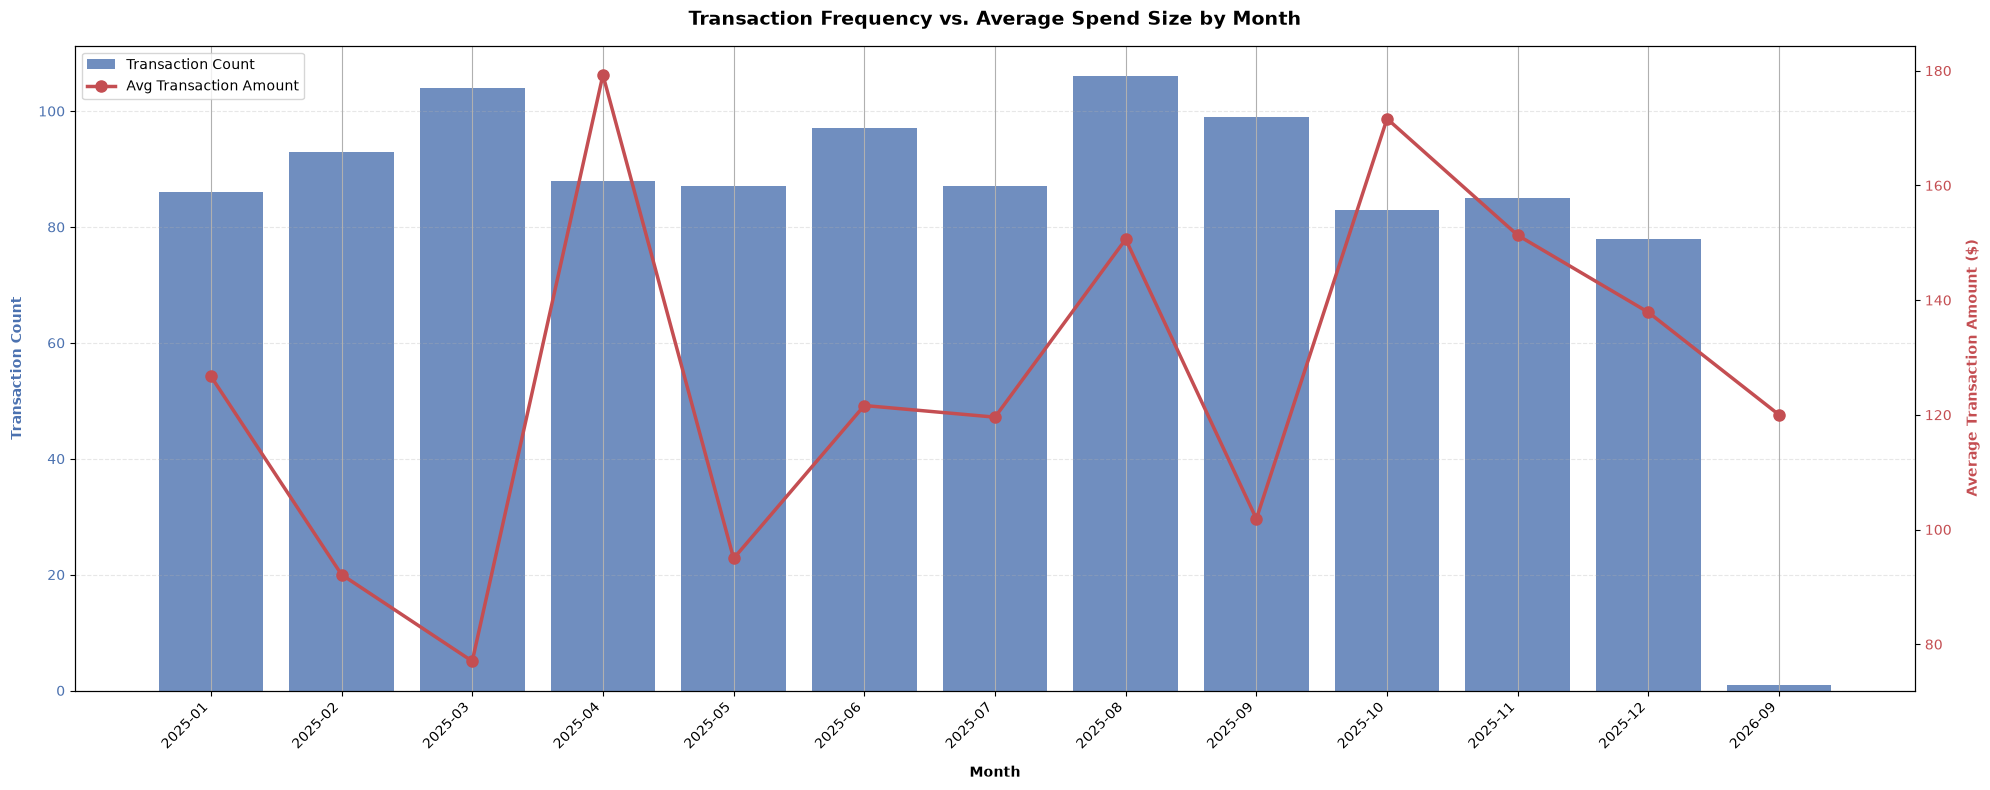

In [ ]:
fig, ax1 = plt.subplots(1, figsize = (20, 8))
ax1.grid()
fig.autofmt_xdate()
color_bars = '#4C72B0' 
ax1.bar(transaction_frequency_vs_avg_spend_size_by_month_df['month'], 
        transaction_frequency_vs_avg_spend_size_by_month_df['transaction_count'], 
        color=color_bars, 
        alpha=0.8, 
        label='Transaction Count'
        )

ax1.set_xlabel('Month', fontweight='bold', labelpad=10)
ax1.set_ylabel('Transaction Count', color=color_bars, fontweight='bold', labelpad=10)
ax1.tick_params(axis='y', labelcolor=color_bars)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()

color_line = '#C44E52'
ax2.plot(transaction_frequency_vs_avg_spend_size_by_month_df['month'], 
         transaction_frequency_vs_avg_spend_size_by_month_df['avg_transaction_amount'], 
         color=color_line, 
         marker='o', 
         linewidth=2.5, 
         markersize=8, 
         label='Avg Transaction Amount')
ax2.set_ylabel('Average Transaction Amount ($)', color=color_line, fontweight='bold', labelpad=10)
ax2.tick_params(axis='y', labelcolor=color_line)

plt.title('Transaction Frequency vs. Average Spend Size by Month', fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)

fig.tight_layout()

plt.show()